<a href="https://colab.research.google.com/github/prackema/KO/blob/main/%5BStudent%5D_Lab_03_ILP1_(Handout_Catering).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Catering Problem

_Combinatorial Optimization course, FEE CTU in Prague. Created by [Industrial Informatics Department](http://industrialinformatics.fel.cvut.cz)._


## Motivation

A catering company to cook $n$ dishes, but has only one available oven.
    At most a single dish can be inside the oven at one time.    
    Each dish $i$ has its earliest time when it can be put into the oven $r_i$ (since it needs to be prepared before it is put into the oven), the latest time it should be taken from the oven $d_i$ (since the customers do not want to wait too long), and the time it needs to stay in the oven $p_i$.
    The goal is to find the vector of times $\mathbf{s} = (s_0, \dots, s_{n-1})$ (denoting the times when each dish is put into the oven) such that the finish time of the last dish is minimal.
    
## Input

You are given the following:
* number of dishes $n$
* parameters $r_i$, $d_i$ and $p_i$ for each dish $i$

For the testing purposes, you can experiment with the following instance:

In [ ]:
!pip install gurobipy
import gurobipy as g  # import Gurobi module

In [ ]:
n = 5
params = {
    0: {'r': 20, 'd': 45, 'p': 15},
    1: {'r':  4, 'd': 30, 'p': 19},
    2: {'r':  5, 'd': 80, 'p': 20},
    3: {'r': 17, 'd': 70, 'p':  8},
    4: {'r': 27, 'd': 66, 'p':  7}
}

# Note: parameter d_1 can be obtained by params[1]["d"]

## Output

You are expected to find the vector $\mathbf{s} = (s_0, \dots, s_{n-1})$ denoting the times when each dish should be put into the oven.

The optimal solution vector for the given instance is $\mathbf{s} = (23, 4, 53, 38, 46)$.

## Exercise

Your task is to formulate the ILP model of the catering problem, solve it, and extract the vector $\mathbf{s}$. The example solution follows:

Hint: to ensure that any two dishes $i$ and $j$ are not overlapping in the oven, you need to ensure that one of the following constraints holds: $s_i + p_i \leq s_j$ or $s_j + p_j \leq s_i$. This might be perhaps done using big-M...

In [ ]:
# model -----------------------------------------------------
model = g.Model()

# - ADD VARIABLES

# - ADD CONSTRAINTS

# - SET OBJECTIVE

model.optimize()

# call the solver -------------------------------------------

# print the solution ----------------------------------------
print('\nSOLUTION:')
# TODO

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 45 rows, 31 columns and 100 nonzeros
Model fingerprint: 0xfa927b2f
Variable types: 0 continuous, 31 integer (25 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 6e+01]
Found heuristic solution: objective 73.0000000
Presolve removed 41 rows and 27 columns
Presolve time: 0.00s
Presolved: 4 rows, 4 columns, 10 nonzeros
Variable types: 0 continuous, 4 integer (1 binary)

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 2 (of 2 available processors)

Solution count 1: 73 

Optimal solution found (tolerance 1.00e-04)
Best objective 7.300000000000e+01, best bound 7.300000000000e+01, gap 0.

## Solution visualization

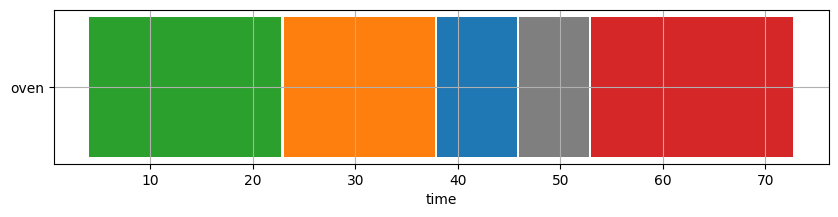

In [ ]:
import matplotlib.pyplot as plt

def plot_solution(s, p):
    """
    s: solution vector
    p: processing times
    """
    fig = plt.figure(figsize=(10,2))
    ax = plt.gca()
    ax.set_xlabel('time')
    ax.grid(True)
    ax.set_yticks([2.5])
    ax.set_yticklabels(["oven"])
    eps = 0.25  # just to show spaces between the dishes
    ax.broken_barh([(s[i], p[i]-eps) for i in range(len(s))], (0, 5),
                   facecolors=('tab:orange', 'tab:green', 'tab:red', 'tab:blue', 'tab:gray'))

# TODO: plot your solution
plot_solution([23.0, 4.0, 53.0, 38.0, 46.0], [params[i]["p"] for i in range(n)])